In [3]:
!pip install lightkurve

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.1/261.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 29.3 MB/s eta 0:00:00
  Created wheel for fbpca: filename=fbpca-1.0-py3-none-any.whl size=11373 sha256=3b15f81257a9e61a05c13fba3d4a407489e401f7d7c5c0fa954117248768ebcf
  Stored in directory: /root/.cache/pip/wheels/04/15/cd/2f622795b09e83471a3be5d2581cd9cf96a6ec7aa78e8deffe
  Created wheel for memoization: filename=memoization-0.4.0-py3-none-any.whl size=50452 sha256=c69b6e35e460fe03fd841a517340010bce5707c46c45548ada20fc9cc978a381
  Stored in directory: /root/.

In [2]:
!pip install transitleastsquares

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.5/47.5 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 53.9 MB/s eta 0:00:00


In [4]:
import lightkurve as lk
import matplotlib.pyplot as plt
from astropy.timeseries import BoxLeastSquares
import numpy as np

# --- PARÂMETROS ---
alvo = "Kepler-423 b"
periodo_lit = 2.684  # Período de referência (NASA Exoplanet Archive)

def pipeline_simples(id_alvo, p_ref):
    """
    Executa a ingestão e auditoria sem filtros de achatamento.
    Retorna: tempo, fluxo, modelo, estatísticas, t0 e duração.
    """
    print(f"📡 Processando {id_alvo} (Apenas Normalização)...")

    # 1. Ingestão
    search = lk.search_lightcurve(id_alvo, author="Kepler", cadence="short")
    if len(search) == 0:
        search = lk.search_lightcurve(id_alvo, author="Kepler", cadence="long")

    # Download e Normalização simples
    lc = search[0].download().remove_nans().normalize()

    # Conversão para arrays
    tempo = np.array(lc.time.jd)
    fluxo = np.array(lc.flux)

    # 2. Análise de Periodicidade
    bls = BoxLeastSquares(tempo, fluxo)
    durations = np.linspace(0.05, 0.2, 20)
    periods = np.linspace(p_ref * 0.9, p_ref * 1.1, 5000)

    results = bls.power(periods, durations)
    best_idx = np.argmax(results.power)

    stats = {
        "periodo": results.period[best_idx],
        "t0": results.transit_time[best_idx],
        "duracao": results.duration[best_idx],
        "snr": results.power[best_idx]
    }

    # Modelo de caixa para visualização
    modelo = bls.model(tempo, stats['periodo'], stats['duracao'], stats['t0'])

    return tempo, fluxo, modelo, stats, stats['t0'], stats['duracao']

# --- EXECUÇÃO ---
try:
    time, flux, modelo_bls, res, t0_final, dur_final = pipeline_simples(alvo, periodo_lit)

    # Cálculo do Erro Relativo (Métrica de Auditoria)
    p_calc = res['periodo']
    erro_relativo = abs(p_calc - periodo_lit) / periodo_lit

    print("-" * 30)
    print(f"✅ AUDITORIA CONCLUÍDA PARA {alvo}:")
    print(f"   - Período Referência: {periodo_lit:.6f} d")
    print(f"   - Período Calculado:  {p_calc:.6f} d")
    print(f"   - Erro Relativo:      {erro_relativo:.2e}")
    print(f"   - SNR (Significância): {res['snr']:.2f}")
    print(f"   - Centro (t0):        {t0_final:.6f} JD")
    print(f"   - Duração:            {dur_final:.4f} d")
    print("-" * 30)

except Exception as e:
    print(f"❌ Erro no Pipeline: {e}")

/usr/local/lib/python3.12/dist-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


📡 Processando Kepler-423 b (Apenas Normalização)...
------------------------------
✅ AUDITORIA CONCLUÍDA PARA Kepler-423 b:
   - Período Referência: 2.684000 d
   - Período Calculado:  2.684376 d
   - Erro Relativo:      1.40e-04
   - SNR (Significância): 0.22
   - Centro (t0):        2455186.470031 JD
   - Duração:            0.0950 d
------------------------------


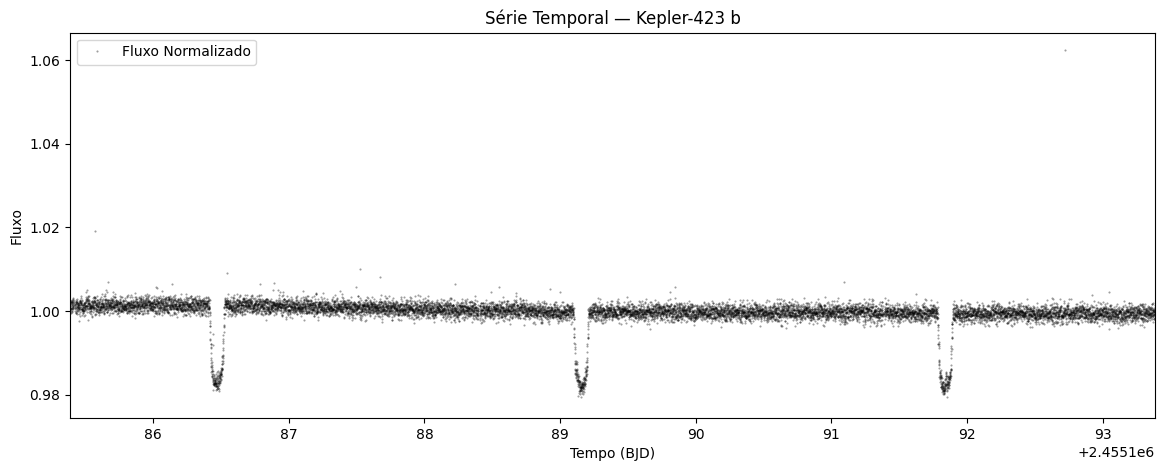

In [5]:
plt.figure(figsize=(14, 5))
plt.plot(time, flux, "k.", markersize=1, alpha=0.4, label="Fluxo Normalizado")

plt.title(f"Série Temporal — {alvo}")
plt.xlabel("Tempo (BJD)")
plt.ylabel("Fluxo")
plt.xlim(time.min(), time.min() + 8)

plt.legend()
plt.show()

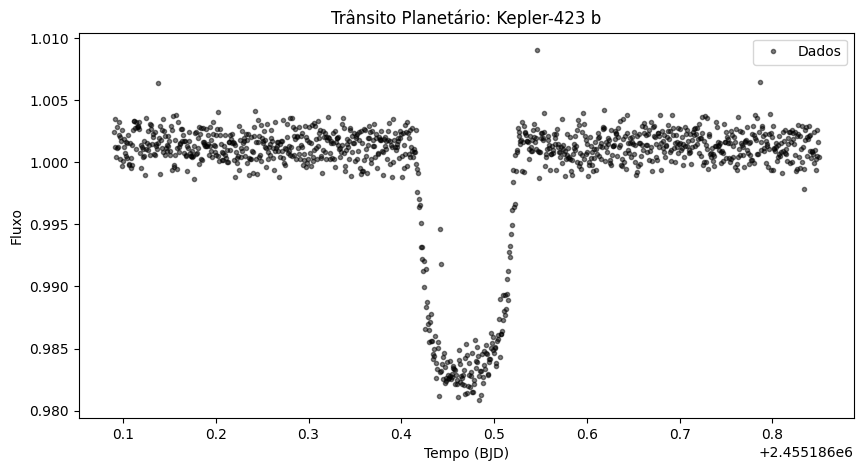

In [8]:
# Janela de visualização ao redor do centro (t0)
janela = res['duracao'] * 4
mask = (time > (res['t0'] - janela)) & (time < (res['t0'] + janela))

plt.figure(figsize=(10, 5))

# Plot dos dados e do modelo
plt.plot(time[mask], flux[mask],"k.", alpha=0.5, label="Dados")

plt.title(f"Trânsito Planetário: {alvo}")
plt.xlabel("Tempo (BJD)")
plt.ylabel("Fluxo")
plt.legend()
plt.show()

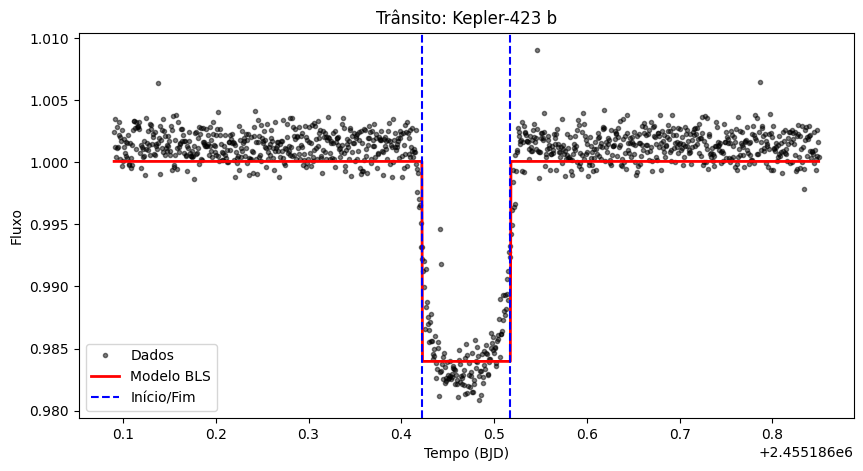

In [6]:
# Janela de visualização ao redor do centro (t0)
janela = res['duracao'] * 4
mask = (time > (res['t0'] - janela)) & (time < (res['t0'] + janela))

plt.figure(figsize=(10, 5))

# Plot dos dados e do modelo
plt.plot(time[mask], flux[mask],"k.", alpha=0.5, label="Dados")
plt.plot(time[mask], modelo_bls[mask], "r-", lw=2, label="Modelo BLS")

# Marcadores de Início e Fim (Ingresso e Egresso)
plt.axvline(res['t0'] - res['duracao']/2, color='b', ls='--', label="Início/Fim")
plt.axvline(res['t0'] + res['duracao']/2, color='b', ls='--')

plt.title(f"Trânsito: {alvo}")
plt.xlabel("Tempo (BJD)")
plt.ylabel("Fluxo")
plt.legend()
plt.show()

In [9]:

from transitleastsquares import transitleastsquares


# --- PARÂMETROS ---
alvo = "Kepler-10 b"
p_ref = 0.8374907  # Período de referência (NASA)
OFFSET_KEPLER = 2454833.0

def pipeline_tls(id_alvo):
    print(f"📡 Iniciando Pipeline TLS para {id_alvo}...")

    # Ingestão e Pré-processamento
    search = lk.search_lightcurve(id_alvo, author="Kepler", cadence="short")
    lc = search[0].download().remove_nans().normalize()

    #Flatten
    lc_flat = lc.flatten(window_length=101).remove_nans()

    tempo = np.array(lc_flat.time.jd)
    fluxo = np.array(lc_flat.flux)

    # Verificação de segurança para o  log
    if np.isnan(fluxo).any():
      print("⚠️ Alerta: Ainda existem NaNs no fluxo!")

    # Execução do Transit Least-Squares (TLS)
    model = transitleastsquares(tempo, fluxo)

    # Executando a busca
    results = model.power(period_min=p_ref*0.9, period_max=p_ref*1.1)


    return tempo, fluxo, results, lc_flat

# --- EXECUÇÃO E COMPARAÇÃO ---
try:

    t, f, res_tls, lc_flat = pipeline_tls(alvo)

    t0_bkjd = res_tls.T0 - OFFSET_KEPLER

    print("-" * 40)
    print(f"✅ RESULTADOS TLS PARA {alvo}:")
    print(f"   - Período Calculado: {res_tls.period:.6f} d")
    print(f"   - SNR (Sinal-Ruído): {res_tls.snr:.2f}")
    print(f"   - SDE (Significância): {res_tls.SDE:.2f}")
    print("-" * 40)

    # Agora o lc_flat existe neste escopo e o fold vai funcionar!
    lc_folded = lc_flat.fold(period=res_tls.period, epoch_time=res_tls.T0)
    lc_binned = lc_folded.bin(time_bin_size=0.01)

except Exception as e:
    print(f"❌ Erro no Pipeline TLS: {e}")

📡 Iniciando Pipeline TLS para Kepler-10 b...
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 19 durations
Searching 43361 data points, 254 periods from 0.754 to 0.921 days
Using all 2 CPU threads


100%|██████████| 254/254 periods | 00:06<00:00


Searching for best T0 for period 0.83747 days
----------------------------------------
✅ RESULTADOS TLS PARA Kepler-10 b:
   - Período Calculado: 0.837472 d
   - SNR (Sinal-Ruído): 4.22
   - SDE (Significância): 8.82
----------------------------------------


/usr/local/lib/python3.12/dist-packages/lightkurve/lightcurve.py:1157: LightkurveWarning: `epoch_time` appears to be given in JD, however the light curve time uses BKJD (i.e. JD - 2454833).
  warnings.warn(


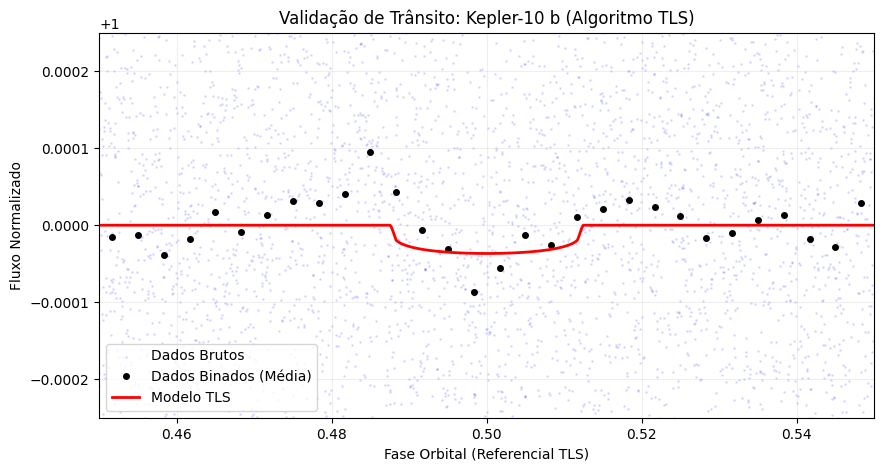

In [10]:

plt.figure(figsize=(10, 5))

    # 1. Dados Brutos (os pontinhos cinzas no fundo)
plt.scatter(res_tls.folded_phase, res_tls.folded_y, color='blue', s=1, alpha=0.1, label='Dados Brutos')

    # 2. Binagem Manual (para os pontos pretos ficarem em cima da linha vermelha)
    # Dividimos a fase (0 a 1) em 100 pedaços e tiramos a média de cada um
# 1. Aumentamos o número de bins de 100 para 300 para ter mais pontos na queda
bin_means, bin_edges = np.histogram(res_tls.folded_phase, bins=300, weights=res_tls.folded_y)
bin_counts, _ = np.histogram(res_tls.folded_phase, bins=300)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
fluxo_binado = bin_means / bin_counts

plt.plot(bin_centers, fluxo_binado, 'ko', markersize=4, label='Dados Binados (Média)')

    # 3. Modelo TLS (a linha vermelha)
plt.plot(res_tls.model_folded_phase, res_tls.model_folded_model, color='red', lw=2, label='Modelo TLS')

    # 4. Ajuste de Escala
plt.xlim(0.45, 0.55)

# 3. Ajuste o zoom vertical para a queda preencher o gráfico
plt.ylim(0.99975, 1.00025)
plt.title(f"Validação de Trânsito: {alvo} (Algoritmo TLS)")
plt.xlabel("Fase Orbital (Referencial TLS)")
plt.ylabel("Fluxo Normalizado")
plt.legend()
plt.grid(alpha=0.2)
plt.show()